In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json


In [ ]:
# Load the data to examine its structure
file_path = '/content/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnet18_UH_stage1_results.csv'

df = pd.read_csv(file_path)
df['per_class_accuracy'] = df['per_class_accuracy']/100
# Display the first few rows of the dataframe to understand its structure
df.head()

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history
0,resnet18-UH-sgd-step-CrossEntropyLoss(),cross_entropy,sgd,step,0.00001,512,0.784903,0.287924,1816.121344,3642.902424,"{'train_loss': [1.212277708635924, 0.850402917..."
1,resnet18-UH-sgd-step-CrossEntropyLoss(),label_smoothing,sgd,step,0.00001,512,0.046107,0.006757,1816.121344,3641.269248,"{'train_loss': [1.8442622537887428, 1.56532328..."
2,resnet18-UH-sgd-cos-CrossEntropyLoss(),cross_entropy,sgd,cos,0.00000,512,0.782921,0.309441,1816.121344,3568.695335,"{'train_loss': [1.19001367814165, 0.8421871154..."
3,resnet18-UH-sgd-cos-CrossEntropyLoss(),label_smoothing,sgd,cos,0.00000,512,0.787817,0.297993,1816.121344,3604.042956,"{'train_loss': [1.858940369247543, 1.567126789..."
4,resnet18-UH-sgd-ReduceLROnPlateau-CrossEntropy...,cross_entropy,sgd,ReduceLROnPlateau,0.01000,512,0.622342,0.280234,1816.121344,3566.965806,"{'train_loss': [1.195290314832481, 0.850187521..."


# Individual Training Plots

In [ ]:
# for each model, plot the training an validation curves
history = df['history'][0]
model_name = df['model_name'][0]
history = history.replace("\'", "\"")
# load json object
history = json.loads(history)

In [ ]:
# select only rows where optimizer == sgd
df_sgd = df[df['optimizer'] == 'sgd']
for row in df_sgd.iterrows():
  history = row[1]['history']
  model_name = row[1]['model_name']
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

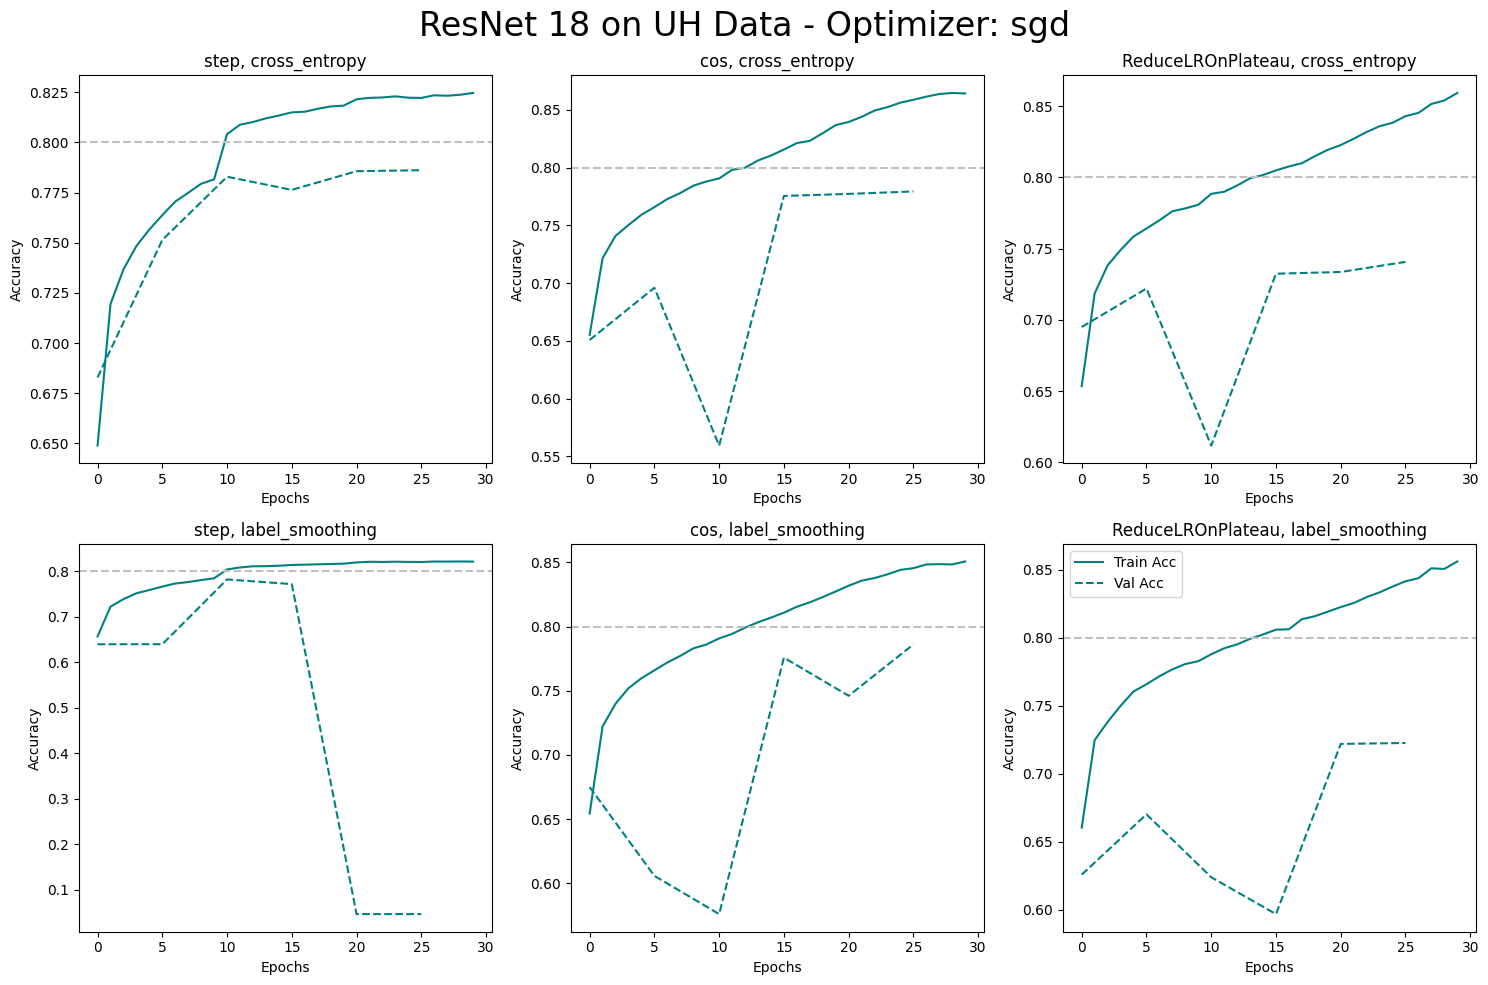

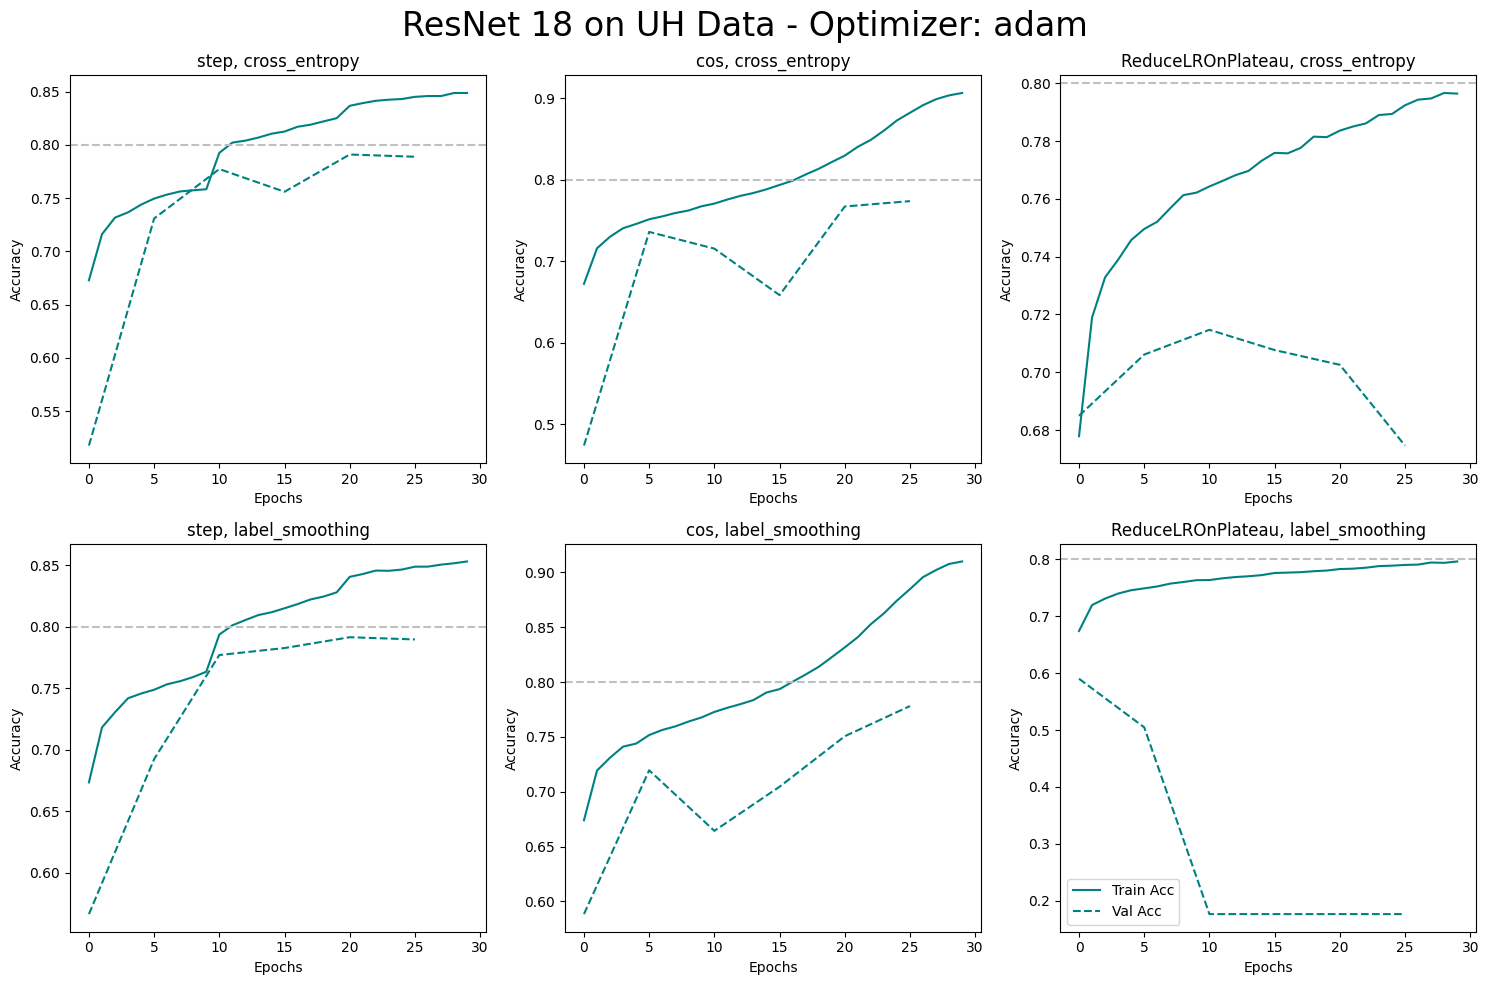

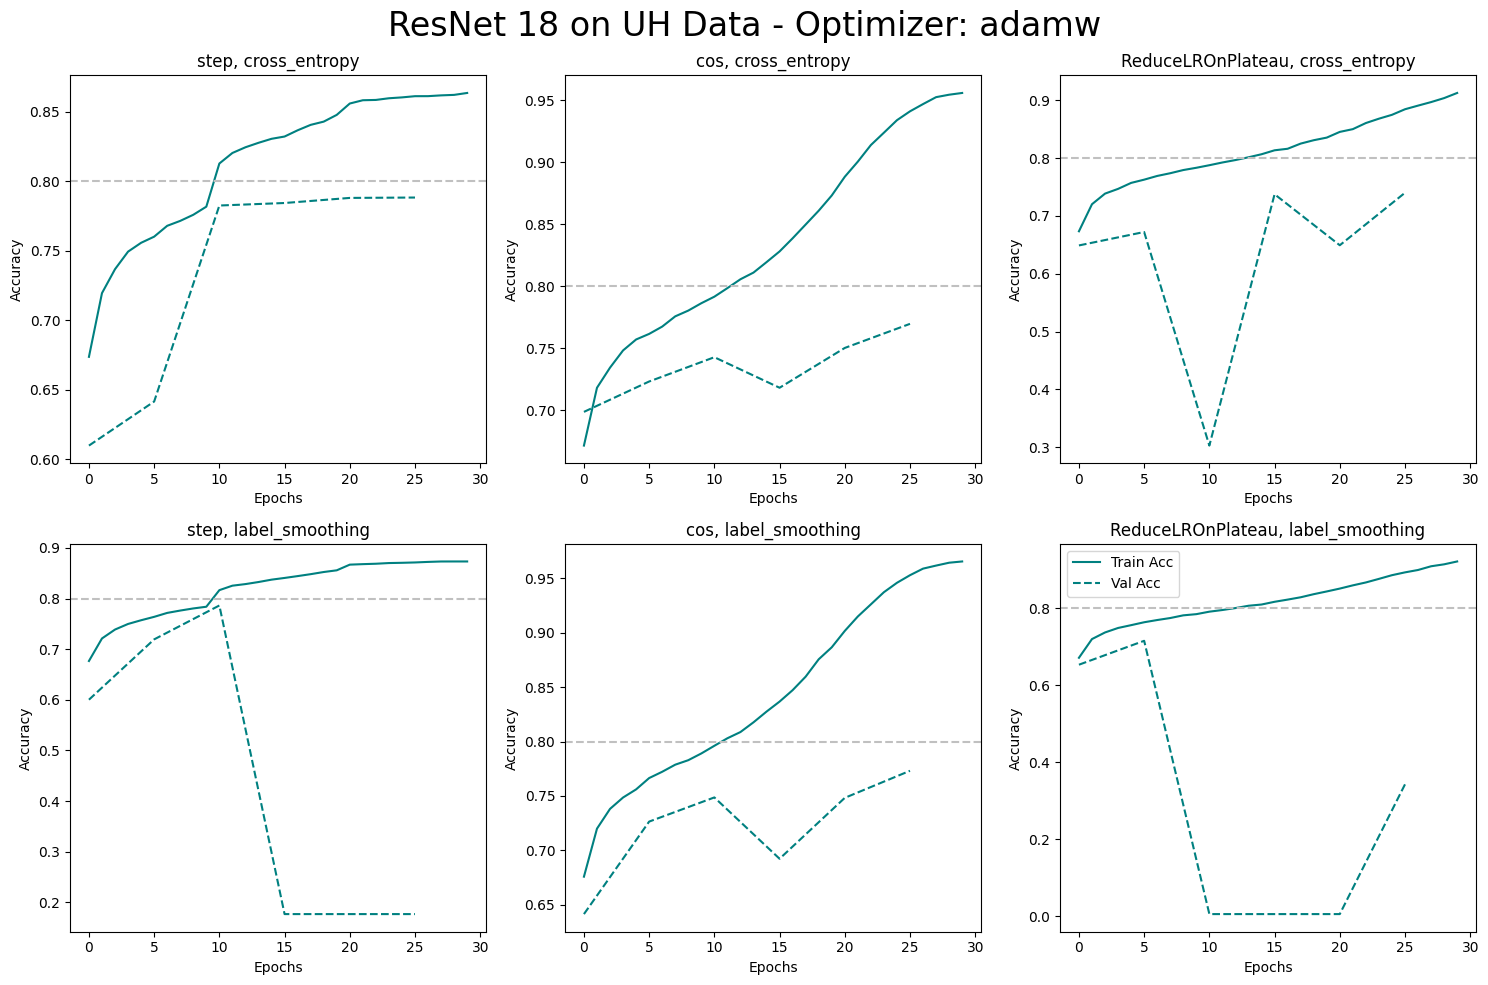

In [ ]:
for opt in df['optimizer'].unique():
  df_sgd = df[df['optimizer'] == opt]
  fig, axes = plt.subplots(2,3, figsize=(15,10))
  for ax, row in zip(axes.flatten(order='F'), df_sgd.iterrows()):
    history = row[1]['history']
    model_name = f"{row[1]['scheduler']}, {row[1]['loss_function']}"
    history = history.replace("\'", "\"")
    history = json.loads(history)
    ax.set_title(model_name, fontdict={"fontsize":12})
    ax.plot(history['train_acc'], label='Train Acc', color='teal')
    ax.plot(history['val_epochs'], history['val_acc'], label='Val Acc', color='teal', ls='--')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    # horizontal dashed line at .80
    ax.axhline(y=.80, color='silver', linestyle='--')
  ax.legend()
  plt.suptitle(f"ResNet 18 on UH Data - Optimizer: {opt}", size=24)

  plt.tight_layout()
  plt.show()

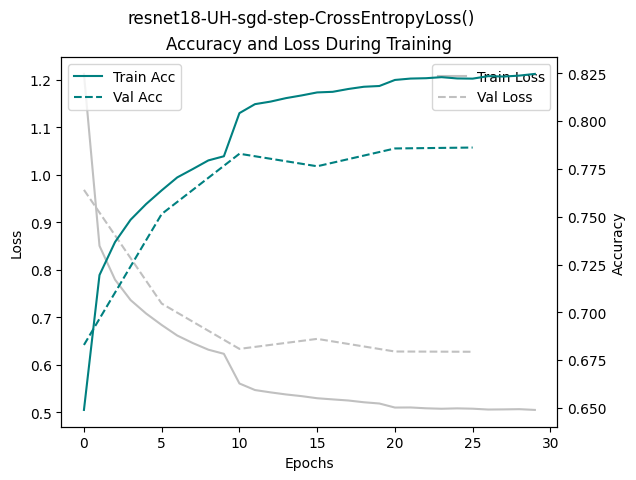

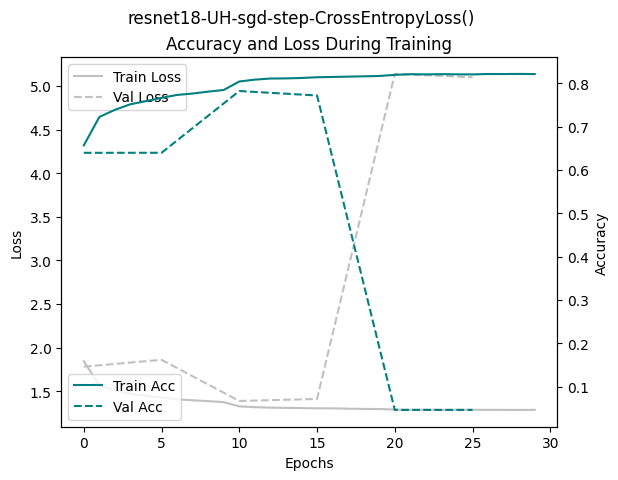

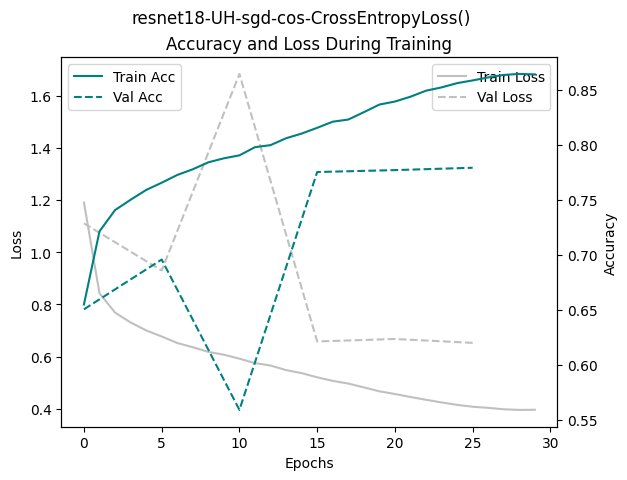

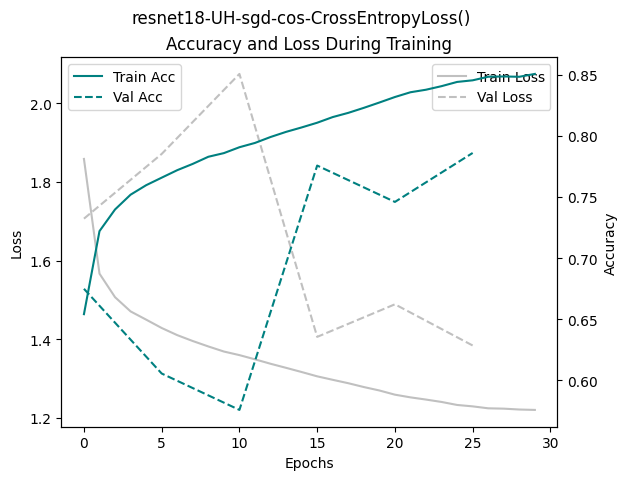

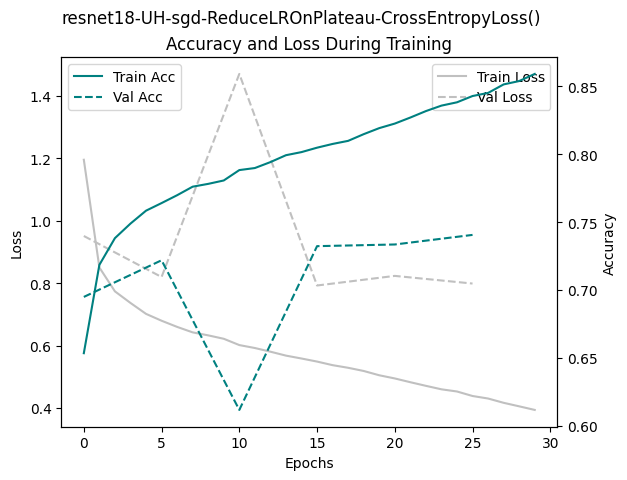

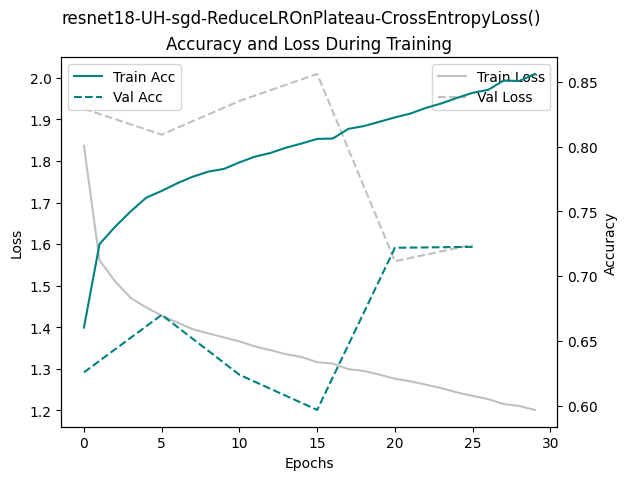

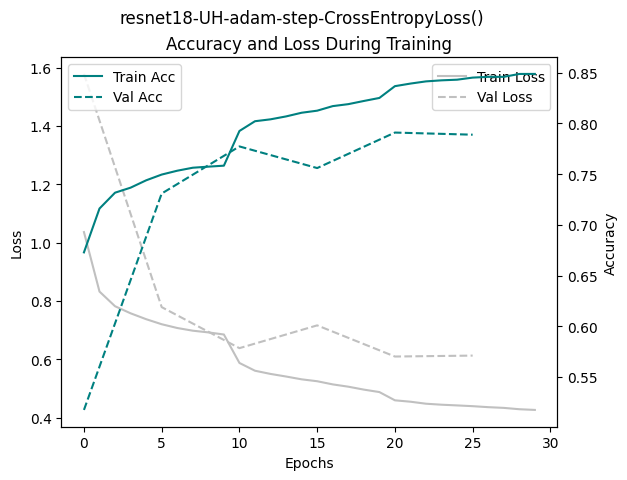

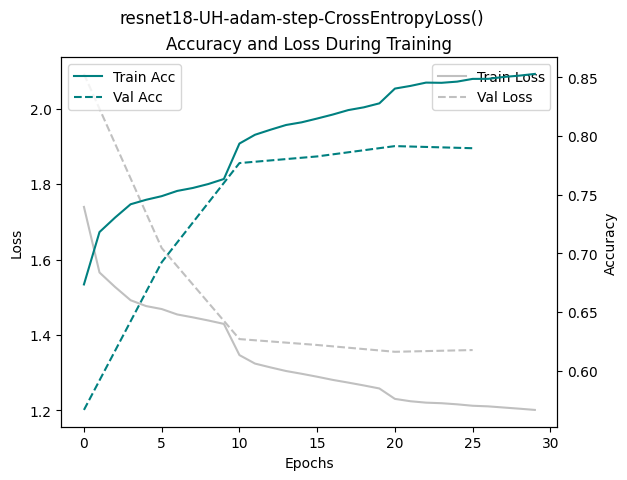

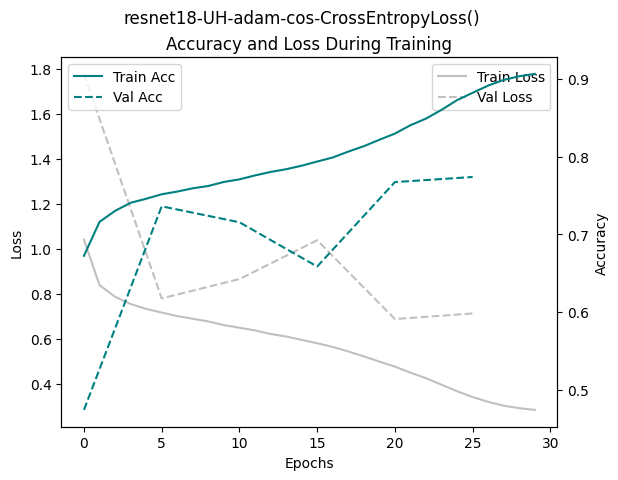

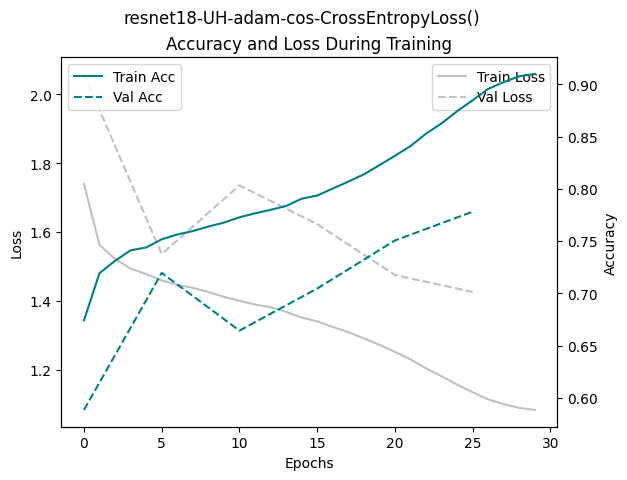

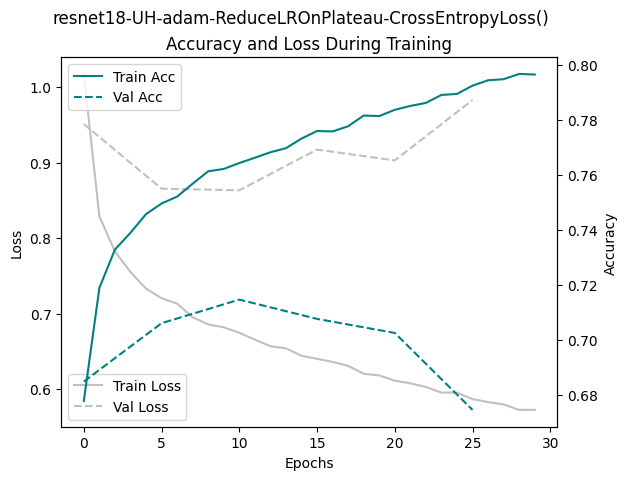

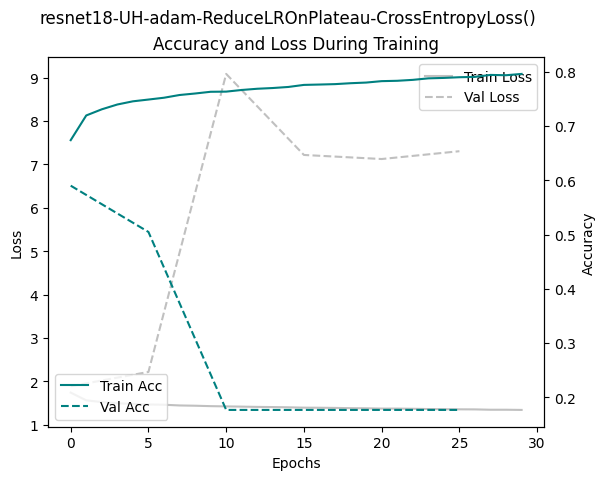

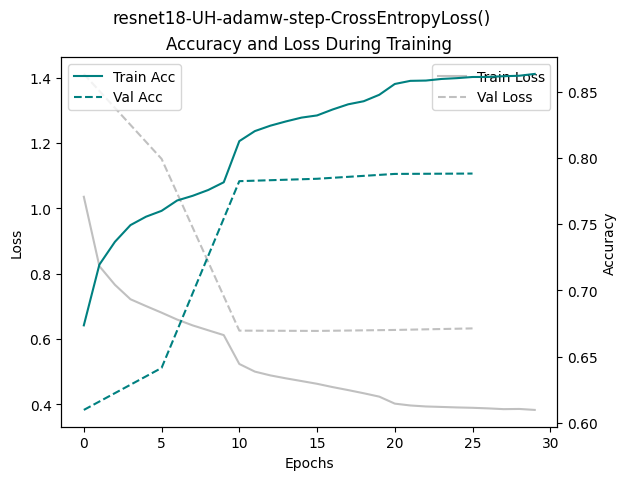

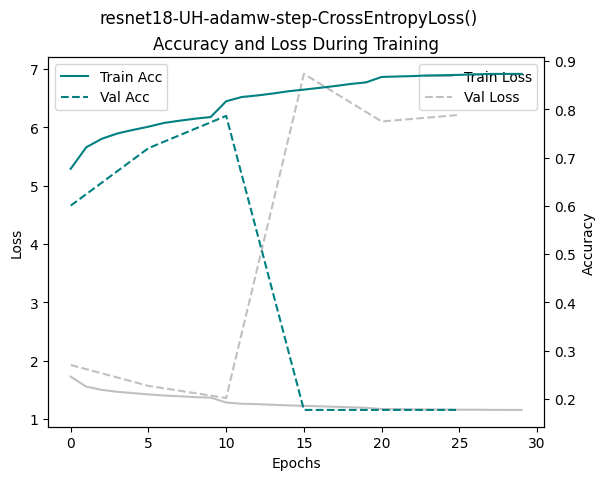

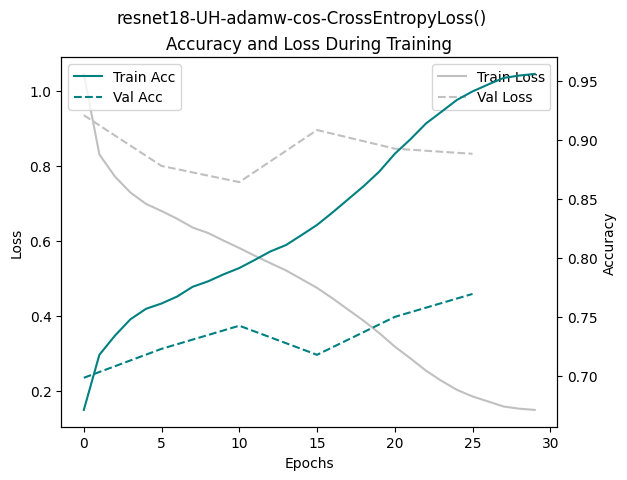

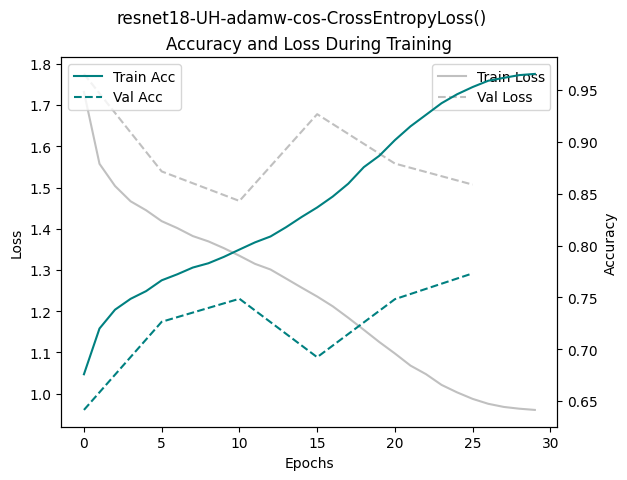

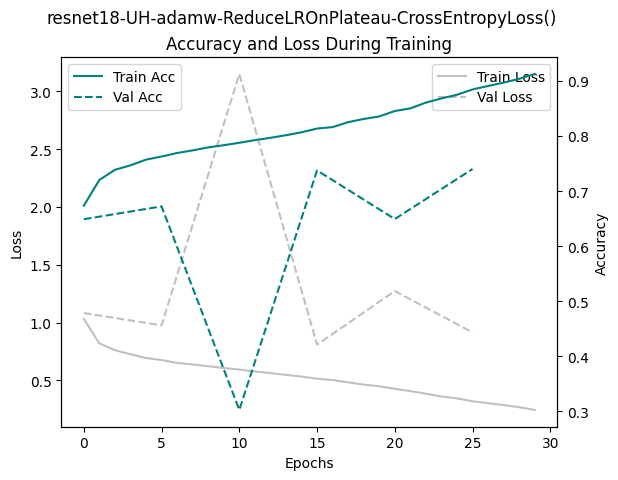

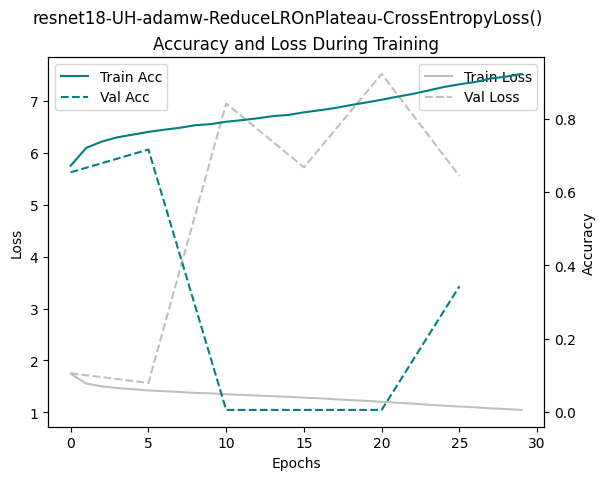

In [ ]:
# Plot Accuracy and Loss
for i in range(len(df)):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  fig, ax = plt.subplots()
  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax.legend()
  plt.suptitle(f"{model_name}")
  plt.show()

# Model Comparison Plots

## Accuracy of models

In [ ]:
df[['model_name', 'per_image_accuracy']].sort_values(by='per_image_accuracy', ascending=False)

,model_name,per_image_accuracy
7,resnet18-UH-adam-step-CrossEntropyLoss(),0.790130
6,resnet18-UH-adam-step-CrossEntropyLoss(),0.788898
3,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.787817
12,resnet18-UH-adamw-step-CrossEntropyLoss(),0.786946
0,resnet18-UH-sgd-step-CrossEntropyLoss(),0.784903
2,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.782921
9,resnet18-UH-adam-cos-CrossEntropyLoss(),0.780728
8,resnet18-UH-adam-cos-CrossEntropyLoss(),0.777905
15,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772708
14,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772528


## Per-Image vs Per-Class

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


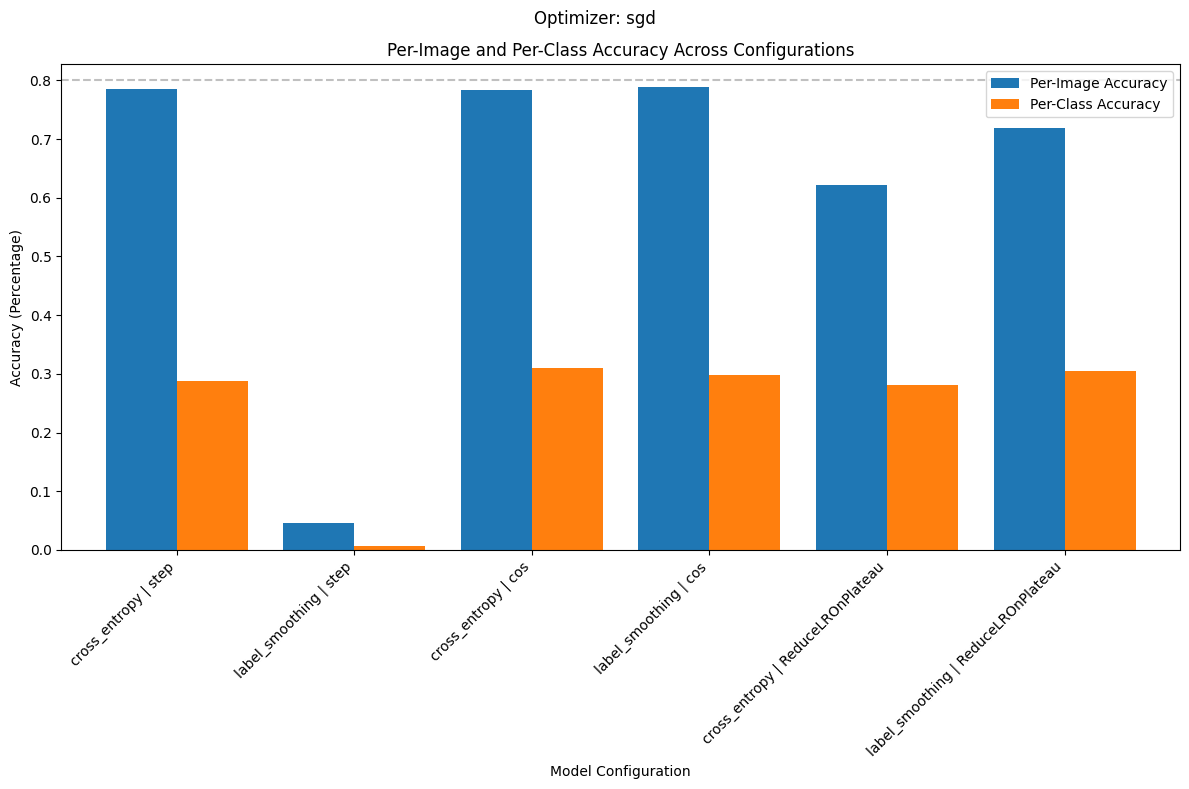

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


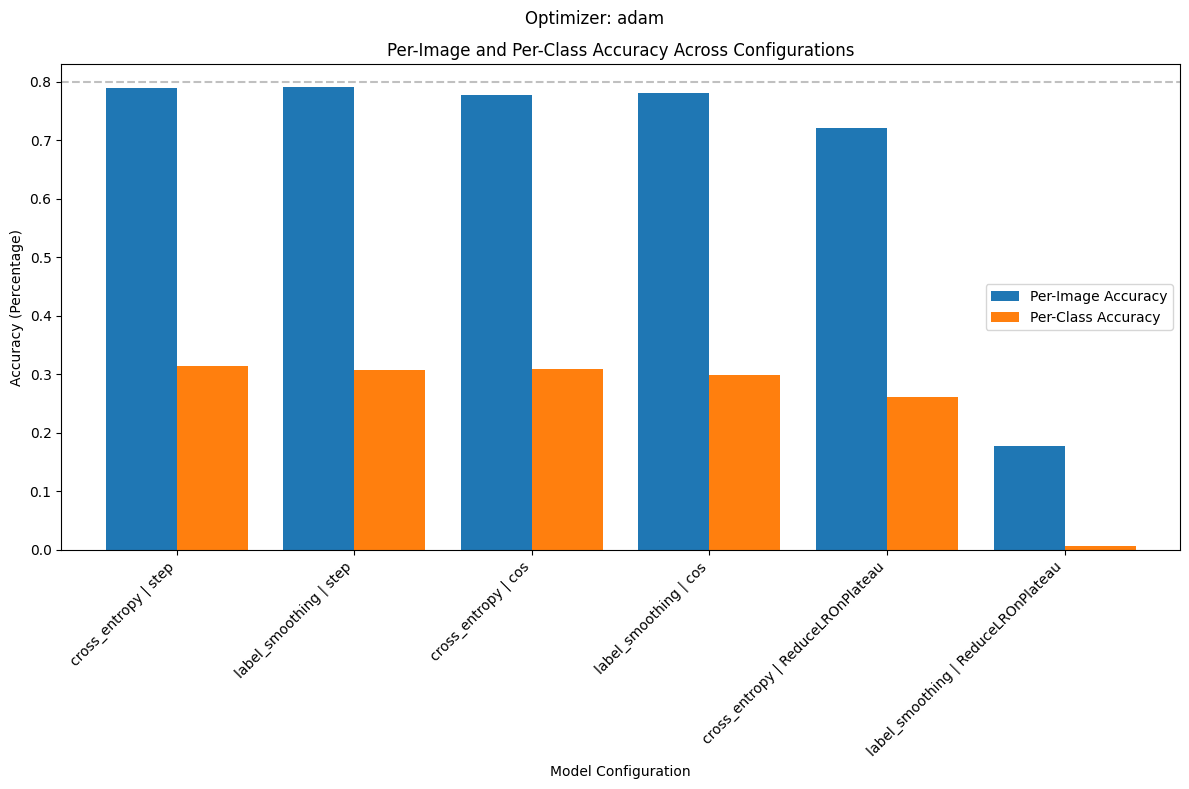

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


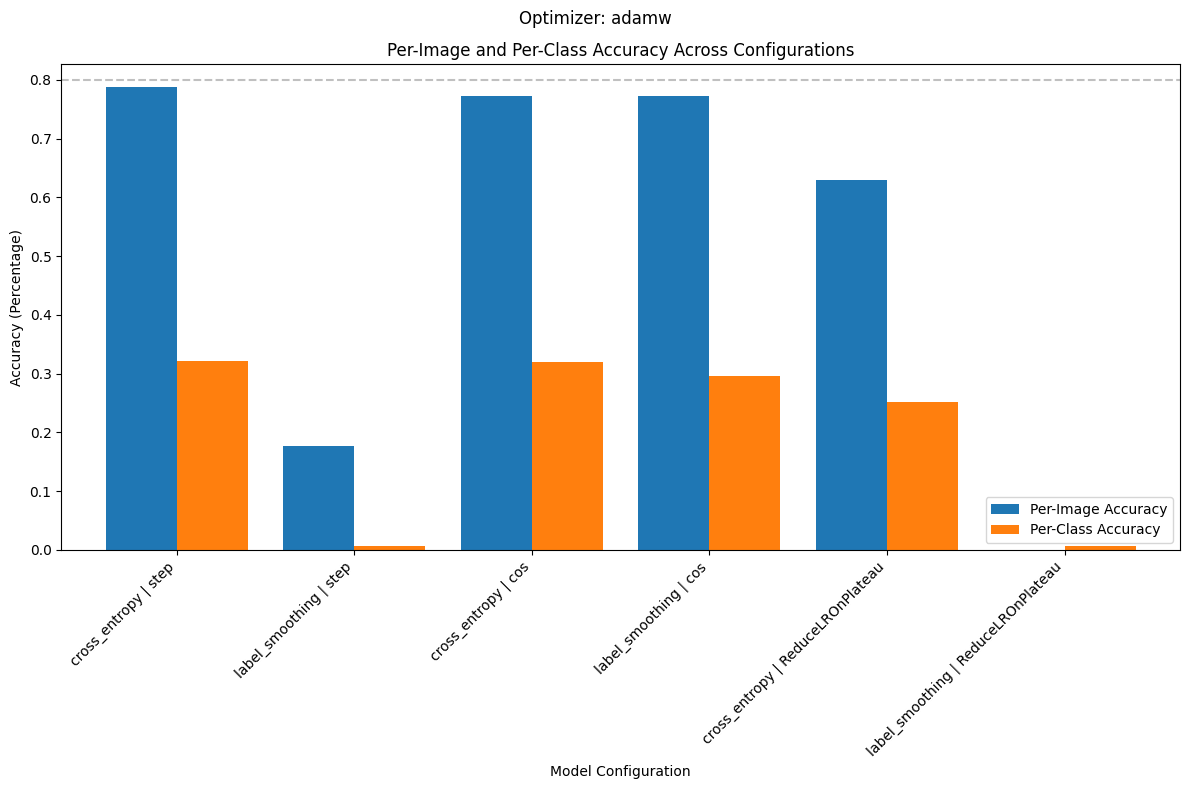

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','per_image_accuracy', 'per_class_accuracy']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Per-Image and Per-Class Accuracy Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("Accuracy (Percentage)")
  plt.xticks(rotation=45, ha="right")
  plt.legend(["Per-Image Accuracy", "Per-Class Accuracy"])
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()


## Wall Time

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


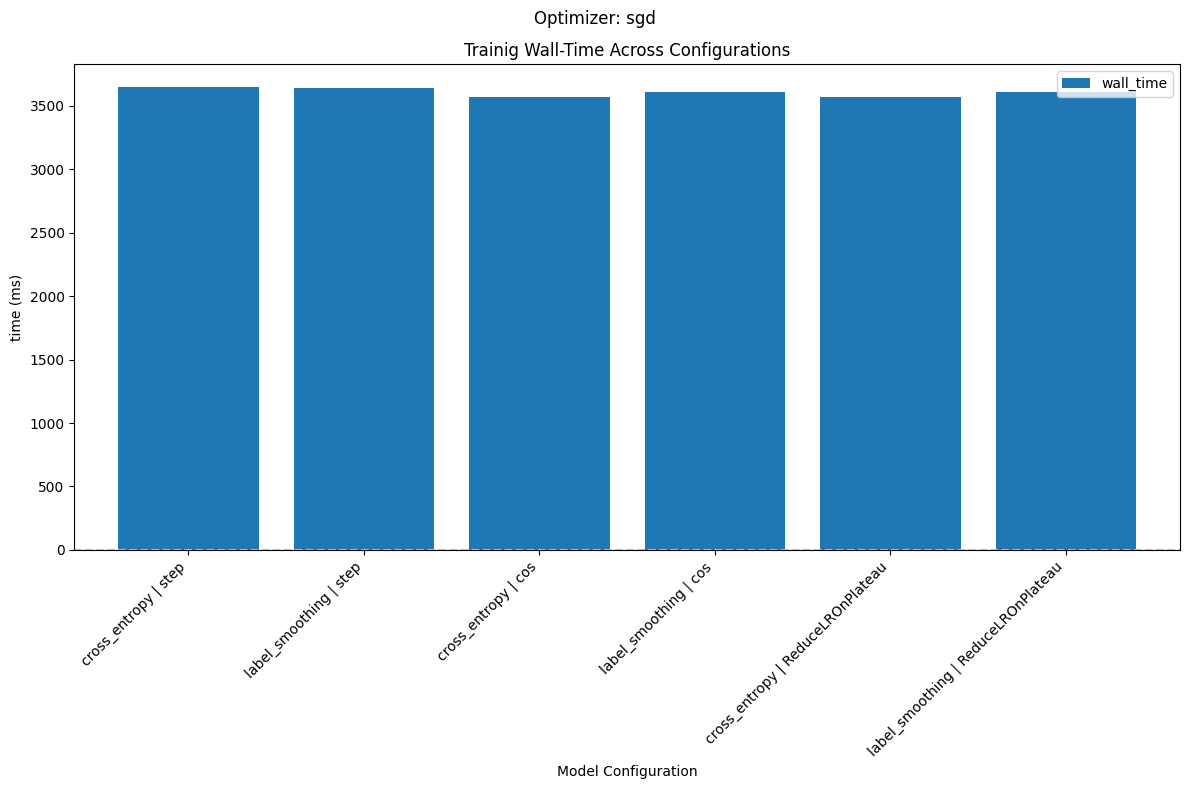

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


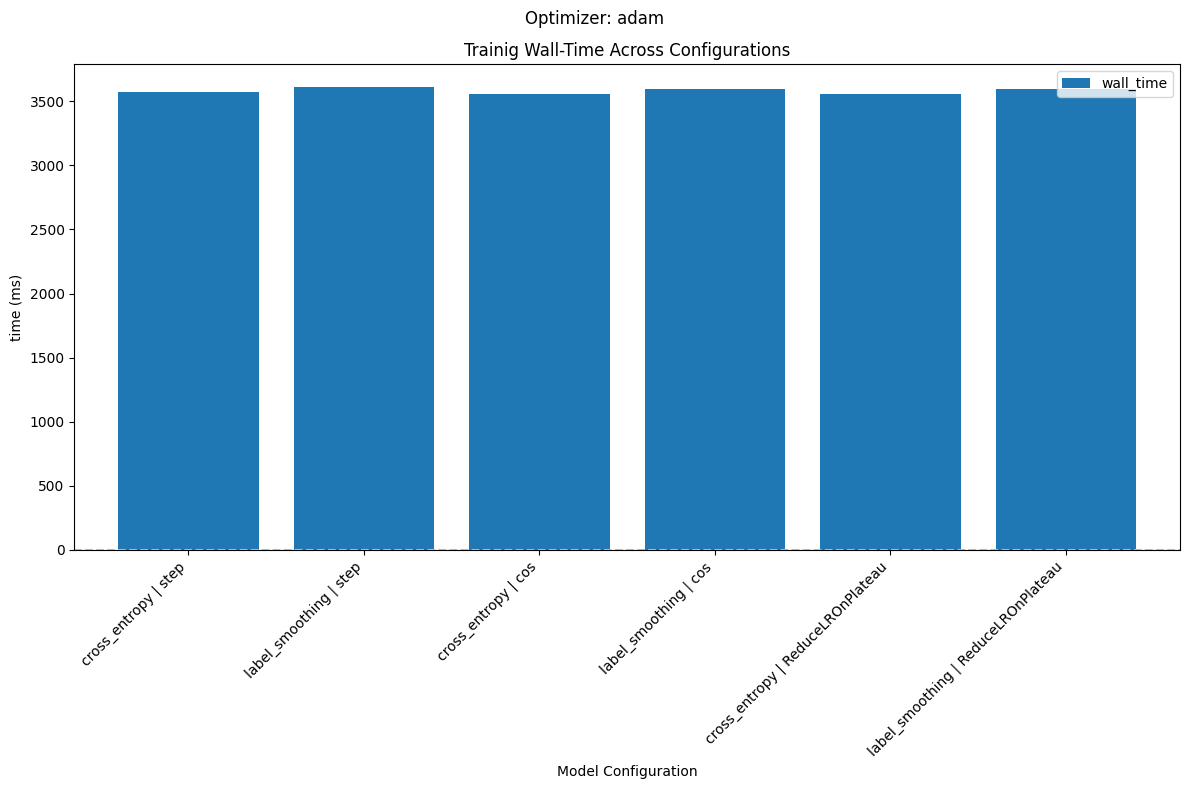

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


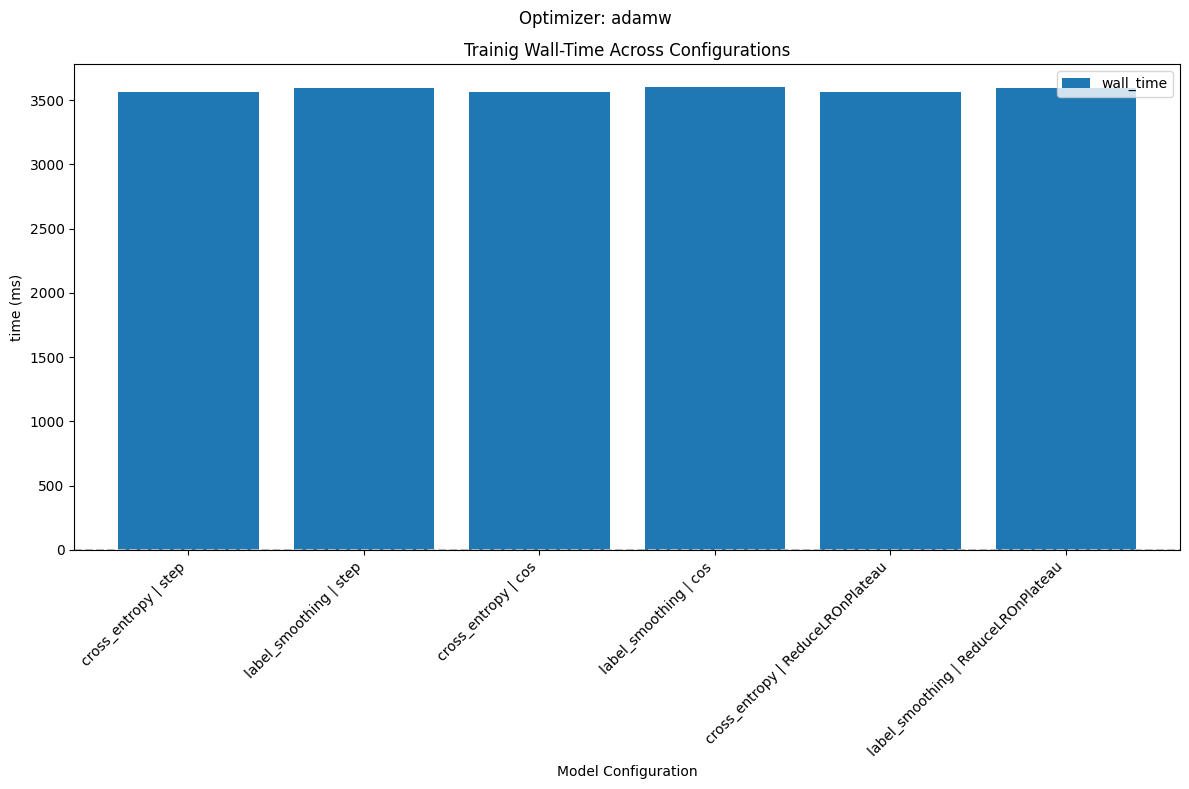

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','wall_time']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Trainig Wall-Time Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("time (ms)")
  plt.xticks(rotation=45, ha="right")
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()